In [1]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn

from tokenizer import DigitTokenizer
from data_stream import MultiplicationModuloDataStream
from lattice_multiplication_transformer import (
    LatticeMultiplicationLoopTransformer,
)
from multiplication_training import (
    create_training_history,
    train_model,
    save_checkpoint,
    load_checkpoint,
    evaluate_model,
)


device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

batch_size = 64
max_seq_len = 128

d_model = 256
rows_per_step = 16
nhead = 4
num_encoder_layers = 2
num_decoder_layers = 2
dim_feedforward = 4 * d_model
dropout = 0.1

learning_rate = 1e-4
weight_decay = 0.1
gradient_clip_norm = 1.0

validation_interval = 100
validation_steps = 20
plot_interval = 100
checkpoint_interval = 10_000

use_bf16 = (
    device.type == "cuda"
    and torch.cuda.is_bf16_supported()
)

if device.type == "cuda":
    torch.set_float32_matmul_precision(
        "high"
    )

print("Device:", device)
print("BF16:", use_bf16)

Device: cuda
BF16: True


In [2]:
tokenizer = DigitTokenizer()

pad_id = tokenizer.char_to_int["<pad>"]
eos_id = tokenizer.char_to_int["<eos>"]

data_stream = MultiplicationModuloDataStream(
    tokenizer=tokenizer,
    batch_size=batch_size,
    max_seq_len=max_seq_len,
    initial_max=20,
    growth_rate=0.0,
    beta_alpha=2.0,
    beta_beta=5.0,
    rehearsal_fraction=0.2,
    rehearsal_max=100,
    max_operand_multiple=3,
    seed=42,
)

model = LatticeMultiplicationLoopTransformer(
    vocab_size=tokenizer.vocab_size,
    pad_id=pad_id,
    max_seq_len=max_seq_len,
    d_model=d_model,
    rows_per_step=rows_per_step,
    nhead=nhead,
    num_encoder_layers=num_encoder_layers,
    num_decoder_layers=num_decoder_layers,
    dim_feedforward=dim_feedforward,
    dropout=dropout,
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay,
)

loss_function = nn.CrossEntropyLoss(
    ignore_index=pad_id,
)

training_history = create_training_history()

parameter_count = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(
    f"Trainable parameters: {parameter_count:,}"
)

print(
    "Operand sequence length:",
    data_stream.operand_seq_len,
)

print(
    "Product sequence length:",
    data_stream.product_seq_len,
)

/teamspace/studios/this_studio/SAIR-competition-modular-math/lattice_multiplication_transformer.py:85: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


Trainable parameters: 12,003,856
Operand sequence length: 128
Product sequence length: 257


In [ ]:
# save_checkpoint(
#     file_name="multiplication_model_step_3000.pt",
#     model=model,
#     optimizer=optimizer,
#     data_stream=data_stream,
#     training_history=training_history,
# )

In [ ]:
# load_checkpoint(
#     file_name="multiplication_model_step_3000.pt",
#     model=model,
#     optimizer=optimizer,
#     data_stream=data_stream,
#     training_history=training_history,
#     device=device,
# )

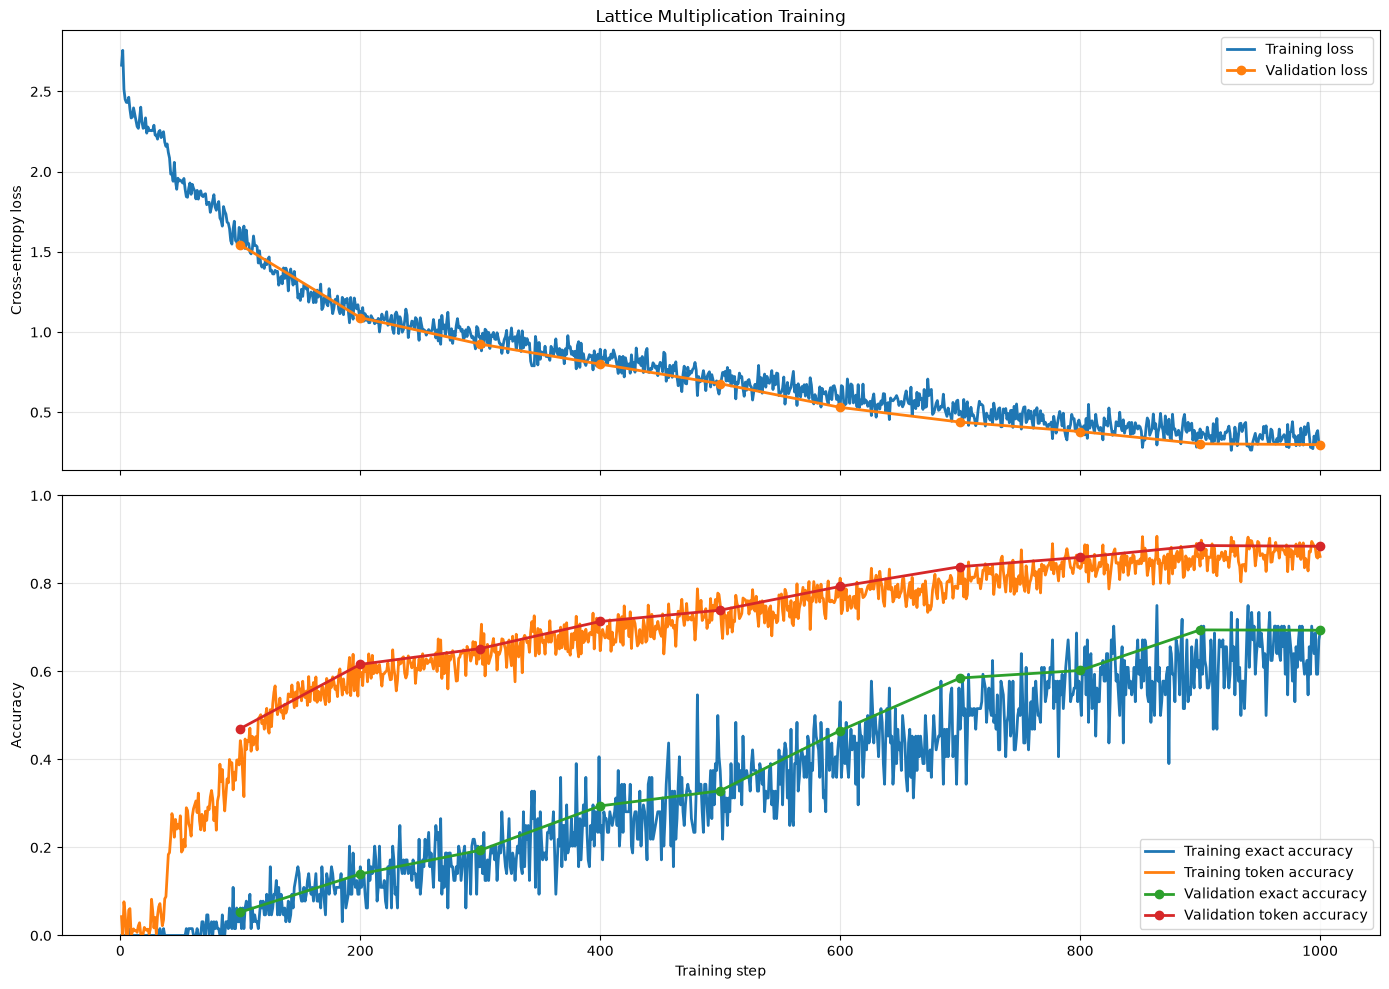

Training multiplication:   0%|          | 0/1000 [00:00<?, ?it/s]

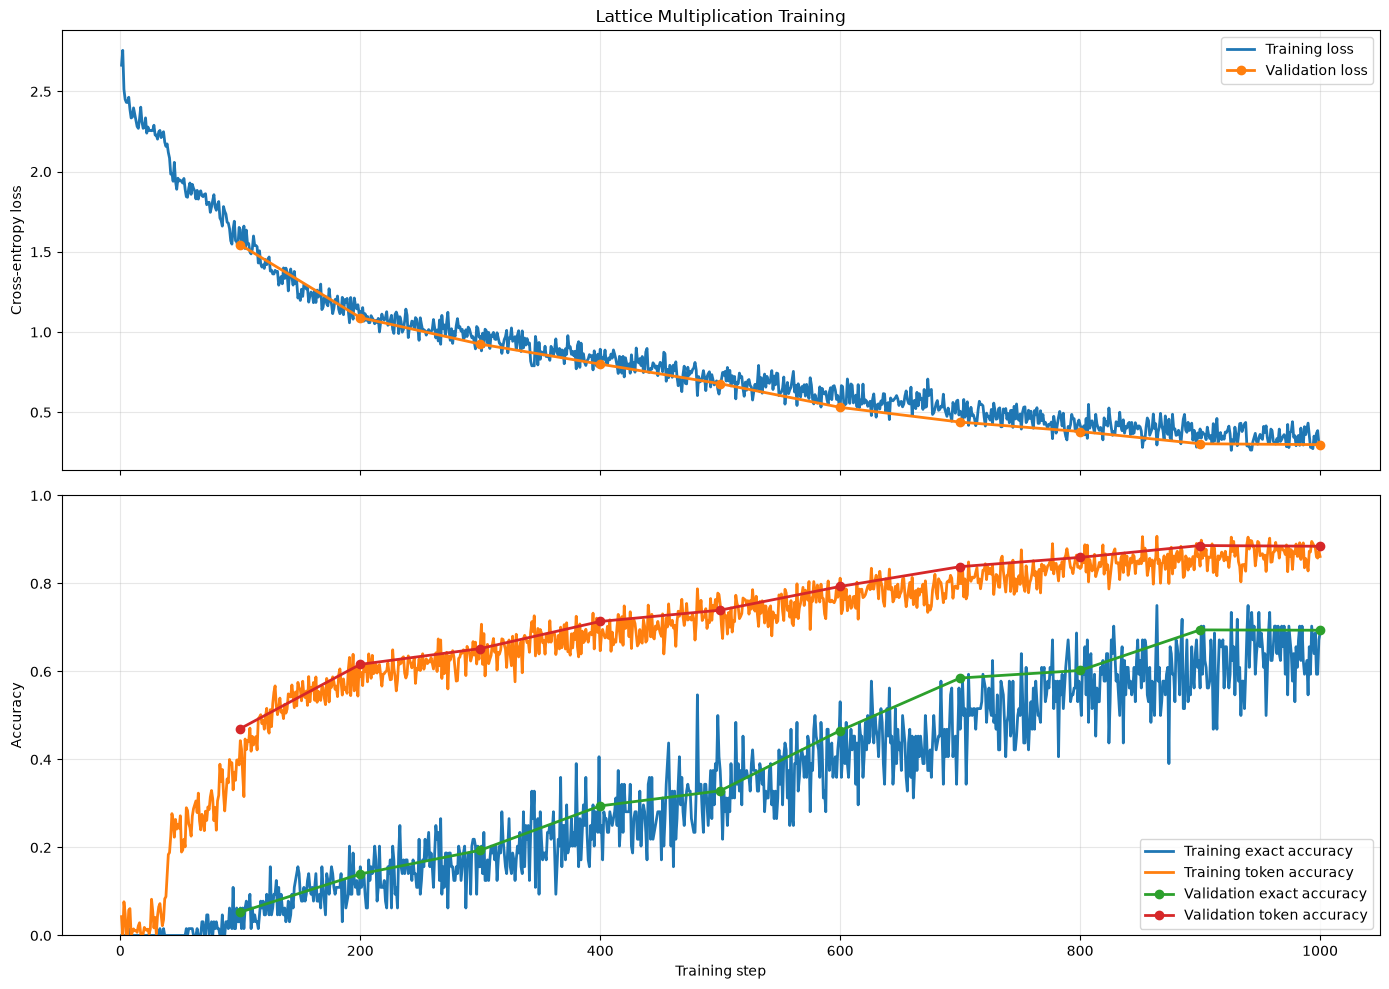

In [3]:
train_model(
    steps=1_000,
    model=model,
    data_stream=data_stream,
    optimizer=optimizer,
    loss_function=loss_function,
    tokenizer=tokenizer,
    device=device,
    training_history=training_history,
    batch_size=batch_size,
    validation_interval=validation_interval,
    validation_steps=validation_steps,
    plot_interval=plot_interval,
    checkpoint_name="lattice_multiplication.pt",
    checkpoint_interval=checkpoint_interval,
    gradient_clip_norm=gradient_clip_norm,
    use_bf16=use_bf16,
)

In [ ]:
evaluate_model(
    model=model,
    data_stream=data_stream,
    tokenizer=tokenizer,
    device=device,
    max_value=100,
    number_of_samples=1_000,
    batch_size=batch_size,
    use_bf16=use_bf16,
)